# Lab 1: Symmetric Cipher Model 

In [2]:
import base64


def xor_encrypt_decrypt(data: bytes, key: bytes) -> bytes:
    """XOR each byte of data with the corresponding byte of the key (repeating key)."""
    return bytes(d ^ key[i % len(key)] for i, d in enumerate(data))


def main():
    print("====================================")
    print("     XOR ENCRYPTION / DECRYPTION")
    print("====================================")

    message = input("Enter a message: ")

    while True:
        key = input("Enter a secret key: ")
        if key != "":
            break
        print("Error: Secret key cannot be empty. Please try again.")

    plaintext = message.encode()
    key_bytes = key.encode()

    ciphertext = xor_encrypt_decrypt(plaintext, key_bytes)
    decrypted = xor_encrypt_decrypt(ciphertext, key_bytes)

    print("\nOriginal message:")
    print(message)

    print("\nEncrypted message (hex):")
    print(ciphertext.hex())

    print("\nEncrypted message (Base64):")
    print(base64.b64encode(ciphertext).decode())

    print("\nDecrypted message:")
    print(decrypted.decode())

    print("\nVerification:")
    if decrypted == plaintext:
        print("SUCCESS: Decryption matches the original message.")
    else:
        print("ERROR: Decryption does not match the original message.")

    print("====================================")


if __name__ == "__main__":
    main()



     XOR ENCRYPTION / DECRYPTION


Enter a message:  Hello
Enter a secret key:  H12



Original message:
Hello

Encrypted message (hex):
00545e245e

Encrypted message (Base64):
AFReJF4=

Decrypted message:
Hello

Verification:
SUCCESS: Decryption matches the original message.


# lab 2: Cryptographic Systems

In [4]:

import hashlib
 
def encrypt(plaintext: bytes, key: bytes) -> bytes:
    return bytes(p ^ key[i % len(key)] for i, p in enumerate(plaintext))
 
def decrypt(ciphertext: bytes, key: bytes) -> bytes:
    return encrypt(ciphertext, key)  # XOR is symmetric, so encrypt() == decrypt()
 
def sender(message: str, key: bytes):
    plaintext = message.encode()
    ciphertext = encrypt(plaintext, key)
    digest = hashlib.sha256(plaintext).hexdigest()   # used later for the integrity check
    print(f"[Sender] Plaintext : {message}")
    print(f"[Sender] Ciphertext (hex): {ciphertext.hex()}")
    print(f"[Sender] SHA-256 digest sent alongside ciphertext: {digest}")
    return ciphertext, digest
 
def receiver(ciphertext: bytes, key: bytes, digest_received: str):
    recovered = decrypt(ciphertext, key)
    digest_check = hashlib.sha256(recovered).hexdigest()
    print(f"[Receiver] Decrypted plaintext: {recovered.decode()}")
    if digest_check == digest_received:
        print("[Receiver] Integrity check PASSED - message was not altered.")
    else:
        print("[Receiver] Integrity check FAILED - message may have been tampered with.")
 
if __name__ == "__main__":
    shared_key = b"SECRETKEY"
    print("--- Both parties already share 'shared_key' in advance ---\n")
    cipher, digest = sender("Meet me at 10pm", shared_key)
    print("\n--- ciphertext + digest travel over an insecure channel ---\n")
    receiver(cipher, shared_key, digest)


--- Both parties already share 'shared_key' in advance ---

[Sender] Plaintext : Meet me at 10pm
[Sender] Ciphertext (hex): 1e20262665392e6538276572623539
[Sender] SHA-256 digest sent alongside ciphertext: 414f121c77cad559e61d41345191aa73aa7cf9c7d5b92eb00ba146001d94d85b

--- ciphertext + digest travel over an insecure channel ---

[Receiver] Decrypted plaintext: Meet me at 10pm
[Receiver] Integrity check PASSED - message was not altered.


In [5]:
def encrypt(plaintext: bytes, key: bytes) -> bytes:
    return bytes(p ^ key[i % len(key)] for i, p in enumerate(plaintext))
 
def eve_intercepts(ciphertext: bytes):
    """Eve has NO key - she can only see the raw ciphertext bytes."""
    print("[Eve] Intercepted ciphertext (hex):", ciphertext.hex())
    try:
        text = ciphertext.decode()
        print("[Eve] Successfully read it as text:", text)
    except UnicodeDecodeError:
        print("[Eve] Ciphertext is NOT readable text - confidentiality holds.")
 
if __name__ == "__main__":
    key = b"SECRETKEY"
    message = b"Launch codes: 4471"
    ciphertext = encrypt(message, key)
 
    print("[Sender] Sends ciphertext over the insecure channel...\n")
    eve_intercepts(ciphertext)


[Sender] Sends ciphertext over the insecure channel...

[Eve] Intercepted ciphertext (hex): 1f24363c263c6b26363720306865607f7268
[Eve] Successfully read it as text: $6<&<k&67 0he`rh


In [6]:
import hashlib
 
def encrypt(plaintext: bytes, key: bytes) -> bytes:
    return bytes(p ^ key[i % len(key)] for i, p in enumerate(plaintext))
 
def decrypt(ciphertext: bytes, key: bytes) -> bytes:
    return encrypt(ciphertext, key)
 
if __name__ == "__main__":
    key = b"SECRETKEY"
    message = b"Transfer $100 to Bob"
 
    ciphertext = encrypt(message, key)
    digest_sent = hashlib.sha256(message).hexdigest()
    print("[Sender] Original ciphertext (hex):", ciphertext.hex())
 
    # --- Simulate an attacker flipping one byte in transit ---
    tampered = bytearray(ciphertext)
    tampered[5] ^= 0xFF
    tampered = bytes(tampered)
    print("[Attacker] Tampered ciphertext (hex):", tampered.hex())
 
    # --- Receiver checks integrity using the digest sent earlier ---
    recovered = decrypt(tampered, key)
    digest_check = hashlib.sha256(recovered).hexdigest()
 
    print("[Receiver] Decrypted (possibly corrupted) message:", recovered)
    if digest_check == digest_sent:
        print("[Receiver] Integrity check PASSED.")
    else:
        print("[Receiver] Integrity check FAILED - message was tampered with in transit!")
 


[Sender] Original ciphertext (hex): 0737223c36322e377977747362652024651b3c27
[Attacker] Tampered ciphertext (hex): 0737223c36cd2e377977747362652024651b3c27
[Receiver] Decrypted (possibly corrupted) message: b'Trans\x99er $100 to Bob'
[Receiver] Integrity check FAILED - message was tampered with in transit!


# Lab 3: Cryptanalysis and Brute-Force Attack

In [8]:
import time
 
def caesar_encrypt(text: str, shift: int) -> str:
    result = []
    for ch in text:
        if ch.isalpha():
            base = ord('A') if ch.isupper() else ord('a')
            result.append(chr((ord(ch) - base + shift) % 26 + base))
        else:
            result.append(ch)
    return "".join(result)
 
def caesar_decrypt(text: str, shift: int) -> str:
    return caesar_encrypt(text, -shift)
 
def brute_force_caesar(ciphertext: str):
    print("Shift | Candidate plaintext")
    print("-" * 40)
    candidates = []
    for shift in range(26):
        candidate = caesar_decrypt(ciphertext, shift)
        candidates.append(candidate)
        print(f"{shift:>5} | {candidate}")
    return candidates
 
if __name__ == "__main__":
    message = input("Enter plaintext: ")
    key = int(input("Enter shift key (0-25): "))
    cipher = caesar_encrypt(message, key)
    print(f"\nCiphertext: {cipher}")
 
    print("\n--- Brute-force attack (attacker does NOT know the key) ---")
    start = time.perf_counter()
    brute_force_caesar(cipher)
    end = time.perf_counter()
    print(f"\nBrute-forced all 26 possible shifts in {end - start:.6f} seconds.")
    print("Scan the list above for the line that reads as valid English -")
    print("that shift value is the recovered key.")


Enter plaintext:  Homaira
Enter shift key (0-25):  15



Ciphertext: Wdbpxgp

--- Brute-force attack (attacker does NOT know the key) ---
Shift | Candidate plaintext
----------------------------------------
    0 | Wdbpxgp
    1 | Vcaowfo
    2 | Ubznven
    3 | Taymudm
    4 | Szxltcl
    5 | Rywksbk
    6 | Qxvjraj
    7 | Pwuiqzi
    8 | Ovthpyh
    9 | Nusgoxg
   10 | Mtrfnwf
   11 | Lsqemve
   12 | Krpdlud
   13 | Jqocktc
   14 | Ipnbjsb
   15 | Homaira
   16 | Gnlzhqz
   17 | Fmkygpy
   18 | Eljxfox
   19 | Dkiwenw
   20 | Cjhvdmv
   21 | Biguclu
   22 | Ahftbkt
   23 | Zgesajs
   24 | Yfdrzir
   25 | Xecqyhq

Brute-forced all 26 possible shifts in 0.014200 seconds.
Scan the list above for the line that reads as valid English -
that shift value is the recovered key.


In [9]:
import time
import string
 
def caesar_encrypt_generic(text, shift, alphabet):
    n = len(alphabet)
    result = ""
    for ch in text:
        if ch in alphabet:
            idx = alphabet.index(ch)
            result += alphabet[(idx + shift) % n]
        else:
            result += ch
    return result
 
def brute_force_time(ciphertext, alphabet):
    n = len(alphabet)
    start = time.perf_counter()
    for shift in range(n):
        _ = caesar_encrypt_generic(ciphertext, -shift, alphabet)
    end = time.perf_counter()
    return end - start, n
 
if __name__ == "__main__":
    plaintext = "THISISASECRETMESSAGE"
 
    alphabets = {
        "26-char (standard Caesar)": string.ascii_uppercase,
        "36-char (A-Z + 0-9)": string.ascii_uppercase + string.digits,
        "95-char (all printable ASCII)": "".join(chr(i) for i in range(32, 127)),
    }
 
    print(f"{'Keyspace':32}{'Size':>8}{'Brute-force time':>22}")
    print("-" * 62)
    for name, alphabet in alphabets.items():
        cipher = caesar_encrypt_generic(plaintext, 5, alphabet)
        elapsed, size = brute_force_time(cipher, alphabet)
        print(f"{name:32}{size:>8}{elapsed:>22.6f} s")
 
    print("\nEven a 95-character keyspace is brute-forced in microseconds -")
    print("this is why simple shift ciphers stay cryptographically weak")
    print("no matter how large the alphabet is; real security needs keyspaces")
    print("like AES's 2^128, which is computationally infeasible to search.")
 


Keyspace                            Size      Brute-force time
--------------------------------------------------------------
26-char (standard Caesar)             26              0.000300 s
36-char (A-Z + 0-9)                   36              0.000400 s
95-char (all printable ASCII)         95              0.001300 s

Even a 95-character keyspace is brute-forced in microseconds -
this is why simple shift ciphers stay cryptographically weak
no matter how large the alphabet is; real security needs keyspaces
like AES's 2^128, which is computationally infeasible to search.


# Lab 4: Encryption Scheme Security

In [1]:
import math
 
def keyspace_report():
    ciphers = {
        "Caesar Cipher": 26,
        "Monoalphabetic Substitution": math.factorial(26),
        "Vigenere (key length 6, 26 letters)": 26 ** 6,
        "DES (56-bit key)": 2 ** 56,
        "AES-128": 2 ** 128,
        "AES-256": 2 ** 256,
    }
 
    # Assumption: attacker can test 10^9 (one billion) keys per second
    speed = 10 ** 9
 
    print(f"{'Cipher':35}{'Keyspace':>18}{'Est. brute-force time':>30}")
    print("-" * 83)
    for name, size in ciphers.items():
        seconds = size / speed
        years = seconds / (60 * 60 * 24 * 365)
        time_str = f"{years:.2e} years" if years > 1e6 else f"{seconds:.2e} seconds"
        print(f"{name:35}{size:>18.3e}{time_str:>30}")
 
if __name__ == "__main__":
    keyspace_report()


Cipher                                       Keyspace         Est. brute-force time
-----------------------------------------------------------------------------------
Caesar Cipher                               2.600e+01              2.60e-08 seconds
Monoalphabetic Substitution                 4.033e+26                1.28e+10 years
Vigenere (key length 6, 26 letters)         3.089e+08              3.09e-01 seconds
DES (56-bit key)                            7.206e+16              7.21e+07 seconds
AES-128                                     3.403e+38                1.08e+22 years
AES-256                                     1.158e+77                3.67e+60 years


In [2]:
from cryptography.fernet import Fernet
 
# ---------- Weak cipher: Caesar (keyspace = 26) ----------
def caesar_encrypt(text, shift):
    result = ""
    for ch in text:
        if ch.isalpha():
            base = ord('A') if ch.isupper() else ord('a')
            result += chr((ord(ch) - base + shift) % 26 + base)
        else:
            result += ch
    return result
 
# ---------- Strong cipher: AES-128 (via Fernet, keyspace = 2^128) ----------
def aes_encrypt(text, key):
    return Fernet(key).encrypt(text.encode())
 
def aes_decrypt(token, key):
    return Fernet(key).decrypt(token).decode()
 
if __name__ == "__main__":
    message = "Meet me at the north gate at midnight"
 
    weak_cipher = caesar_encrypt(message, 7)
    print("=== WEAK CIPHER: Caesar (shift = 7) ===")
    print("Ciphertext:", weak_cipher)
    print("Keyspace  : 26 possible keys -> broken by brute force in milliseconds\n")
 
    aes_key = Fernet.generate_key()
    strong_cipher = aes_encrypt(message, aes_key)
    print("=== STRONG CIPHER: AES-128 (Fernet) ===")
    print("Ciphertext:", strong_cipher.decode())
    print("Keyspace  : 2^128 possible keys -> practically unbreakable by brute force")
    print("Decrypted :", aes_decrypt(strong_cipher, aes_key))
 
    print("\nNotice the AES ciphertext shows no visible relationship to the plaintext,")
    print("while the Caesar ciphertext still preserves word boundaries and letter")
    print("patterns that a human reader or frequency analysis could exploit.")
 


=== WEAK CIPHER: Caesar (shift = 7) ===
Ciphertext: Tlla tl ha aol uvyao nhal ha tpkupnoa
Keyspace  : 26 possible keys -> broken by brute force in milliseconds

=== STRONG CIPHER: AES-128 (Fernet) ===
Ciphertext: gAAAAABqqLEulcicxNHtI5hnqbY2rHy01N-8K7r4lOknp1m3SBpqyDavpbROLyWClZTC-N1B0Xb_bX1bF0zdqcKxUKtREUgW1wMea1k3Uccfrm8H-Yvkzc8fw6sSou59iQ7cxUwXmE4a
Keyspace  : 2^128 possible keys -> practically unbreakable by brute force
Decrypted : Meet me at the north gate at midnight

Notice the AES ciphertext shows no visible relationship to the plaintext,
while the Caesar ciphertext still preserves word boundaries and letter
patterns that a human reader or frequency analysis could exploit.


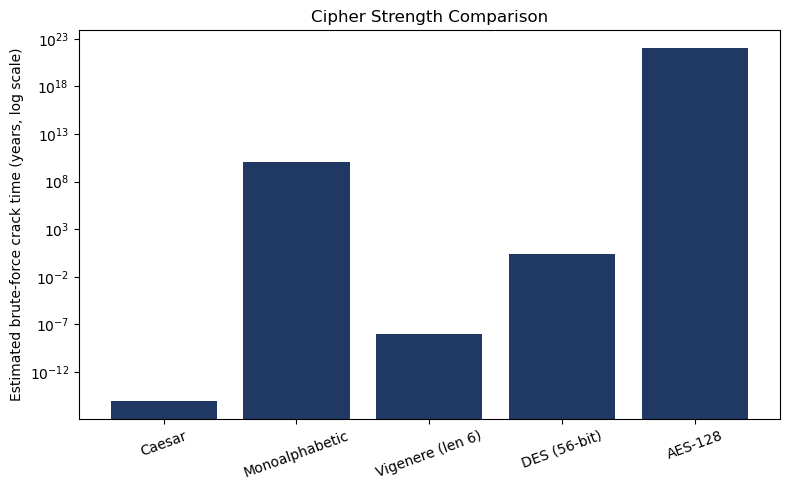

Chart saved as security_assessment_chart.png - insert this into your report.


In [3]:
import math
import matplotlib.pyplot as plt
 
ciphers = {
    "Caesar": 26,
    "Monoalphabetic": math.factorial(26),
    "Vigenere (len 6)": 26 ** 6,
    "DES (56-bit)": 2 ** 56,
    "AES-128": 2 ** 128,
}
speed = 10 ** 9  # assumed attacker speed: keys tested per second
years = {name: (size / speed) / (60 * 60 * 24 * 365) for name, size in ciphers.items()}
 
plt.figure(figsize=(8, 5))
plt.bar(years.keys(), years.values(), color="#1F3864")
plt.yscale("log")
plt.ylabel("Estimated brute-force crack time (years, log scale)")
plt.title("Cipher Strength Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("security_assessment_chart.png")
plt.show()
print("Chart saved as security_assessment_chart.png - insert this into your report.")


# Lab 5: Caesar Cipher


In [ ]:
def caesar_encrypt(text, shift):
    result = ""
    for ch in text:
        if ch.isalpha():
            base = ord('A') if ch.isupper() else ord('a')
            result += chr((ord(ch) - base + shift) % 26 + base)
        else:
            result += ch
    return result
 
def caesar_decrypt(text, shift):
    return caesar_encrypt(text, -shift)
 
def brute_force(ciphertext):
    for shift in range(26):
        print(f"Shift {shift:2}: {caesar_decrypt(ciphertext, shift)}")
 
def menu():
    while True:
        print("\n1. Encrypt\n2. Decrypt\n3. Brute-force attack\n4. Exit")
        choice = input("Choose an option: ")
        if choice == "1":
            msg = input("Enter message: ")
            k = int(input("Enter shift key: "))
            print("Ciphertext:", caesar_encrypt(msg, k))
        elif choice == "2":
            msg = input("Enter ciphertext: ")
            k = int(input("Enter shift key: "))
            print("Plaintext:", caesar_decrypt(msg, k))
        elif choice == "3":
            msg = input("Enter ciphertext to attack: ")
            brute_force(msg)
        elif choice == "4":
            break
        else:
            print("Invalid option.")
 
if __name__ == "__main__":
    menu()


# Lab 6: Monoalphabetic Cipher


In [6]:
import random
import string
from collections import Counter
 
ALPHABET = string.ascii_uppercase
ENGLISH_FREQ_ORDER = "ETAOINSHRDLCUMWFGYPBVKJXQZ"
 
def generate_key():
    shuffled = list(ALPHABET)
    random.shuffle(shuffled)
    return dict(zip(ALPHABET, shuffled))
 
def encrypt(text, key):
    return "".join(key.get(ch.upper(), ch) if ch.isalpha() else ch for ch in text)
 
def decrypt(text, key):
    inverse = {v: k for k, v in key.items()}
    return "".join(inverse.get(ch.upper(), ch) if ch.isalpha() else ch for ch in text)
 
def frequency_analysis(ciphertext):
    letters_only = [ch for ch in ciphertext.upper() if ch.isalpha()]
    freq = Counter(letters_only)
    ranked = [item[0] for item in freq.most_common()]
 
    print("Ciphertext letter frequency (most to least common):")
    for letter, count in freq.most_common():
        print(f"  {letter}: {count}")
 
    print("\nSuggested mapping based on standard English letter frequency order:")
    for i, cipher_letter in enumerate(ranked):
        if i < len(ENGLISH_FREQ_ORDER):
            print(f"  {cipher_letter}  ->  likely '{ENGLISH_FREQ_ORDER[i]}'")
 
if __name__ == "__main__":
    key = generate_key()
    print("Random substitution key:", key)
 
    plaintext = input("Enter a LONG plaintext message (more text = better frequency analysis): ")
    cipher = encrypt(plaintext, key)
    print(f"\nCiphertext: {cipher}")
 
    recovered = decrypt(cipher, key)
    print(f"Decrypted (using known key): {recovered}")
 
    print("\n--- Cryptanalysis: Frequency Analysis Attack ---")
    frequency_analysis(cipher)
 


Random substitution key: {'A': 'P', 'B': 'L', 'C': 'E', 'D': 'T', 'E': 'K', 'F': 'C', 'G': 'J', 'H': 'S', 'I': 'I', 'J': 'Q', 'K': 'R', 'L': 'V', 'M': 'M', 'N': 'F', 'O': 'N', 'P': 'U', 'Q': 'Y', 'R': 'X', 'S': 'G', 'T': 'D', 'U': 'B', 'V': 'A', 'W': 'Z', 'X': 'W', 'Y': 'O', 'Z': 'H'}


Enter a LONG plaintext message (more text = better frequency analysis):  Technology has become an important part of modern life, changing the way people communicate, study, work, travel, and solve problems. In the past, people depended heavily on physical books, handwritten documents, face-to-face meetings, and traditional methods of communication. Today, computers, smartphones, the internet, and artificial intelligence allow people to access information within seconds and communicate with others from almost anywhere in the world. This development has created many opportunities for students, teachers, businesses, researchers, and communities.



Ciphertext: DKESFNVNJO SPG LKENMK PF IMUNXDPFD UPXD NC MNTKXF VICK, ESPFJIFJ DSK ZPO UKNUVK ENMMBFIEPDK, GDBTO, ZNXR, DXPAKV, PFT GNVAK UXNLVKMG. IF DSK UPGD, UKNUVK TKUKFTKT SKPAIVO NF USOGIEPV LNNRG, SPFTZXIDDKF TNEBMKFDG, CPEK-DN-CPEK MKKDIFJG, PFT DXPTIDINFPV MKDSNTG NC ENMMBFIEPDINF. DNTPO, ENMUBDKXG, GMPXDUSNFKG, DSK IFDKXFKD, PFT PXDICIEIPV IFDKVVIJKFEK PVVNZ UKNUVK DN PEEKGG IFCNXMPDINF ZIDSIF GKENFTG PFT ENMMBFIEPDK ZIDS NDSKXG CXNM PVMNGD PFOZSKXK IF DSK ZNXVT. DSIG TKAKVNUMKFD SPG EXKPDKT MPFO NUUNXDBFIDIKG CNX GDBTKFDG, DKPESKXG, LBGIFKGGKG, XKGKPXESKXG, PFT ENMMBFIDIKG.
Decrypted (using known key): TECHNOLOGY HAS BECOME AN IMPORTANT PART OF MODERN LIFE, CHANGING THE WAY PEOPLE COMMUNICATE, STUDY, WORK, TRAVEL, AND SOLVE PROBLEMS. IN THE PAST, PEOPLE DEPENDED HEAVILY ON PHYSICAL BOOKS, HANDWRITTEN DOCUMENTS, FACE-TO-FACE MEETINGS, AND TRADITIONAL METHODS OF COMMUNICATION. TODAY, COMPUTERS, SMARTPHONES, THE INTERNET, AND ARTIFICIAL INTELLIGENCE ALLOW PEOPLE TO ACCESS INFORM

In [8]:
import time
 
def caesar_encrypt(text, shift):
    result = ""
    for ch in text:
        if ch.isalpha():
            base = ord('A') if ch.isupper() else ord('a')
            result += chr((ord(ch) - base + shift) % 26 + base)
        else:
            result += ch
    return result
 
def caesar_decrypt(text, shift):
    return caesar_encrypt(text, -shift)
 
def brute_force_caesar(ciphertext):
    return [caesar_decrypt(ciphertext, s) for s in range(26)]
 
if __name__ == "__main__":
    message = "MEET ME AT THE OLD BRIDGE TONIGHT"
 
    # Caesar cipher: fully broken by exhaustive key search
    caesar_cipher = caesar_encrypt(message, 11)
    start = time.perf_counter()
    candidates = brute_force_caesar(caesar_cipher)
    elapsed = time.perf_counter() - start
    print(f"Caesar cipher brute-forced (all 26 keys tried) in {elapsed:.6f} seconds.")
    print("The correct plaintext is guaranteed to appear among the 26 candidates.\n")
 
    print("A monoalphabetic substitution cipher has 26! (~4x10^26) possible keys,")
    print("making the SAME brute-force approach completely infeasible.")
    print("Instead it must be broken using frequency analysis (see Code Block 1),")
    print("which exploits the STRUCTURE of the language rather than searching keys.")
    print("\nConclusion: Caesar is weak because its KEYSPACE is small.")
    print("Monoalphabetic substitution is also weak, but for a DIFFERENT reason -")
    print("it leaks statistical patterns despite having a huge keyspace.")


Caesar cipher brute-forced (all 26 keys tried) in 0.000400 seconds.
The correct plaintext is guaranteed to appear among the 26 candidates.

A monoalphabetic substitution cipher has 26! (~4x10^26) possible keys,
making the SAME brute-force approach completely infeasible.
Instead it must be broken using frequency analysis (see Code Block 1),
which exploits the STRUCTURE of the language rather than searching keys.

Conclusion: Caesar is weak because its KEYSPACE is small.
Monoalphabetic substitution is also weak, but for a DIFFERENT reason -
it leaks statistical patterns despite having a huge keyspace.


# Lab 7: Playfair Cipher


In [9]:
def generate_matrix(key):
    key = key.upper().replace("J", "I")
    seen = set()
    matrix_letters = []
    for ch in key:
        if ch.isalpha() and ch not in seen:
            seen.add(ch)
            matrix_letters.append(ch)
    for ch in "ABCDEFGHIKLMNOPQRSTUVWXYZ":  # note: no J, merged with I
        if ch not in seen:
            seen.add(ch)
            matrix_letters.append(ch)
    return [matrix_letters[i:i + 5] for i in range(0, 25, 5)]
 
def find_position(matrix, ch):
    for r, row in enumerate(matrix):
        if ch in row:
            return r, row.index(ch)
    return None
 
def prepare_text(text):
    text = text.upper().replace("J", "I")
    text = "".join(ch for ch in text if ch.isalpha())
    digraphs = []
    i = 0
    while i < len(text):
        a = text[i]
        b = text[i + 1] if i + 1 < len(text) else "X"
        if a == b:
            digraphs.append(a + "X")
            i += 1
        else:
            digraphs.append(a + b)
            i += 2
    if len(digraphs[-1]) == 1:
        digraphs[-1] += "X"
    return digraphs
 
def playfair_encrypt(text, key):
    matrix = generate_matrix(key)
    result = ""
    for pair in prepare_text(text):
        r1, c1 = find_position(matrix, pair[0])
        r2, c2 = find_position(matrix, pair[1])
        if r1 == r2:
            result += matrix[r1][(c1 + 1) % 5] + matrix[r2][(c2 + 1) % 5]
        elif c1 == c2:
            result += matrix[(r1 + 1) % 5][c1] + matrix[(r2 + 1) % 5][c2]
        else:
            result += matrix[r1][c2] + matrix[r2][c1]
    return result
 
def playfair_decrypt(cipher, key):
    matrix = generate_matrix(key)
    result = ""
    for i in range(0, len(cipher), 2):
        a, b = cipher[i], cipher[i + 1]
        r1, c1 = find_position(matrix, a)
        r2, c2 = find_position(matrix, b)
        if r1 == r2:
            result += matrix[r1][(c1 - 1) % 5] + matrix[r2][(c2 - 1) % 5]
        elif c1 == c2:
            result += matrix[(r1 - 1) % 5][c1] + matrix[(r2 - 1) % 5][c2]
        else:
            result += matrix[r1][c2] + matrix[r2][c1]
    return result
 
if __name__ == "__main__":
    key = input("Enter Playfair key: ")
    matrix = generate_matrix(key)
    print("\n5x5 Key Matrix:")
    for row in matrix:
        print(" ".join(row))
 
    plaintext = input("\nEnter plaintext: ")
    cipher = playfair_encrypt(plaintext, key)
    print(f"Ciphertext: {cipher}")
 
    decrypted = playfair_decrypt(cipher, key)
    print(f"Decrypted: {decrypted}")
    print("\nNote: repeated letters are split with a filler 'X', and I/J share one cell.")
 


Enter Playfair key:  12



5x5 Key Matrix:
A B C D E
F G H I K
L M N O P
Q R S T U
V W X Y Z



Enter plaintext:  Today, the weather is too hot.


Ciphertext: YTEBDYKCZBDQKCTGTUNYNITY
Decrypted: TODAYTHEWEATHERISTOXOHOT

Note: repeated letters are split with a filler 'X', and I/J share one cell.
